# Clinical Trials Dataset

This project explores a dataset containing a comprehensive collection of clinical trials conducted worldwide up to May 2020 (last dataset update).

The analysis focuses on the following variables:
- study title
- start date
- study first submitted date
- condition
- country
- study type
- completion date

**Research Question**

The primary question addressed in this analysis is:

- How has the focus of clinical trials changed over time?

**Approach**

The project begins with exploratory data analysis to gain an initial understanding of the dataset structure, variable distributions, and potential data quality issues.

The subsequent data cleaning process includes:
- identifying and handling missing values
- checking for duplicate entries
- standardizing naming conventions and text formatting
- converting variables into consistent and comparable formats

After cleaning, additional features are engineered to support the analysis and improve interpretability. These include variables such as study year and broader disease categories derived from clinical conditions.

The final analysis aims to identify temporal trends in clinical trial activity across different research areas.

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import seaborn as sns

## Parse and load data

In [3]:
from xml.etree import ElementTree as ET

In [4]:
def parse_xml(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()

    def get_text(path):
        element = root.find(path)
        return element.text if element is not None else None

    data = {
        "title": get_text("brief_title"),
        "start_date": get_text("start_date"),
        "completion_date": get_text("completion_date"),
        "study_first_submitted": get_text("study_first_submitted"),
        "study_type": get_text("study_type"),
    }

    # Conditions (can be multiple)
    conditions = root.findall("condition")
    data["conditions"] = [c.text for c in conditions if c is not None]

    # Countries (nested structure)
    countries = root.findall(".//location_countries/country")
    data["countries"] = [c.text for c in countries if c is not None]

    return data

In [5]:
pkl_path = "input/all_data.pkl"
if os.path.exists(pkl_path):
    df = pd.read_pickle(pkl_path)
else:
    
    # for this, I need a kaggle token
    import kagglehub
    
    # Download latest version
    path = kagglehub.dataset_download("skylord/all-clinical-trials")
    
    # print("Path to dataset files:", path)
    ! mv $path/*  input/

    # this may take a bit
    path = 'input/'
    files = []
    for subdir in os.listdir(path):
        path_subdir = os.path.join(path, subdir)
        for f in os.listdir(path_subdir):
            if f.endswith('.xml'):
                files.append(os.path.join(path, subdir, f)) 
    data_l = []
    for file in files:
        try:
            parsed_data = parse_xml(file)
            data_l.append(parsed_data)
        except Exception as e:
            print(f'Error with {file}: {e}')
    df = pd.DataFrame(data_l)
    df.to_pickle(pkl_path)
    """ TODO: add zip + removing .xml files here"""

In [6]:
df

,title,start_date,completion_date,study_first_submitted,study_type,conditions,countries
0,Safety and Pharmacodynamic Study of an Oral Ir...,August 2010,January 2013,"August 19, 2010",Interventional,"[Transfusional Iron Overload, Beta-thalassemia]","[Italy, Thailand, Turkey, United Kingdom, Unit..."
1,Integrating Interventions for Maternal Substan...,September 2007,August 2012,"August 23, 2010",Interventional,"[Substance Abuse, Child Neglect]",[United States]
2,Comparing Head and Neck Endoscopy Procedures,September 2010,January 2013,"August 12, 2010",Interventional,[Comparing Head And Neck Endoscopy in Healthy ...,[Canada]
3,Modulation of Brain Plasticity After Perinatal...,August 2010,March 2014,"August 20, 2010",Interventional,"[Stroke, Cerebral Palsy]",[Canada]
4,Efficacy and Safety Study of LE-DT to Treat Me...,June 2010,September 2011,"August 19, 2010",Interventional,[Prostate Cancer],[United States]
...,...,...,...,...,...,...,...
103502,Management of Insomnia in Breast Cancer Patients,January 2011,July 2016,"November 9, 2009",Interventional,"[Insomnia, Fatigue]",[United States]
103503,Perioperative Iron With Erythropoietin in Bila...,August 2008,October 2009,"November 10, 2009",Interventional,"[Anemia, Transfusion]","[Korea, Republic of]"
103504,Human Fetal Liver Cell Transplantation in Chro...,February 2007,July 2011,"November 11, 2009",Interventional,[Liver Cirrhosis],[Italy]
103505,A Study of Imatinib and Valproic Acid in Patie...,September 2009,July 2010,"November 5, 2009",Interventional,[Chronic Myelogenous Leukemia],[United States]


## Data cleaning

### Convert submit_date to datetime

In [7]:
df.study_first_submitted.isna().unique()

array([False])

In [8]:
df.study_first_submitted = pd.to_datetime(df.study_first_submitted)

### Consistent col names?

In [10]:
df.columns

Index(['title', 'start_date', 'completion_date', 'study_first_submitted',
       'study_type', 'conditions', 'countries'],
      dtype='object')

### List entries?

Present in cols 'countries' and 'conditions'

#### Countries

In [11]:
# filter rows wo countries
filter_countries = pd.isna(df.countries.explode())

In [12]:
# or just fillna with unknown
df.countries = df.countries.explode(ignore_index=True)
df.countries = df.countries.fillna('Unknown')

In [13]:
df.countries

0                  Italy
1               Thailand
2                 Turkey
3         United Kingdom
4          United States
               ...      
103502     United States
103503     United States
103504     United States
103505     United States
103506           Unknown
Name: countries, Length: 103507, dtype: object

#### Conditions

In [14]:
df.conditions = df.conditions.explode(ignore_index=True)
df.conditions = df.conditions.fillna('Unknown')

In [15]:
# lower case
df["conditions"] = (df["conditions"].str.lower().str.strip() ) 

In [16]:
# check
df["conditions"].explode().value_counts().head(20)

conditions
hiv infections               1691
breast cancer                1551
healthy                      1464
obesity                       938
hypertension                  859
asthma                        830
prostate cancer               821
lymphoma                      721
schizophrenia                 711
leukemia                      692
lung cancer                   659
pain                          608
depression                    580
diabetes mellitus, type 2     573
colorectal cancer             565
cardiovascular diseases       541
cancer                        530
diabetes                      517
coronary artery disease       495
rheumatoid arthritis          459
Name: count, dtype: int64

## Feature engineering

### Trends in studies

To analyze the trends in studies, I need to:
- Engineer a feature that indicates the year of a study in a comparable manner
- Sort the conditions into broader categories, to make the comparison more distinct

#### Year

In [17]:
df['year'] = df.study_first_submitted.dt.year

In [19]:
studies_per_year = df.groupby('year').size()

In [20]:
studies_per_year

year
1999     3645
2000     1980
2001     1346
2002     1588
2003     1662
2004     1787
2005    12888
2006    10923
2007    13367
2008    16956
2009    17059
2010    17310
2011     2996
dtype: int64

In [21]:
# clean table
studies_per_year = studies_per_year.reset_index(name='num_studies')

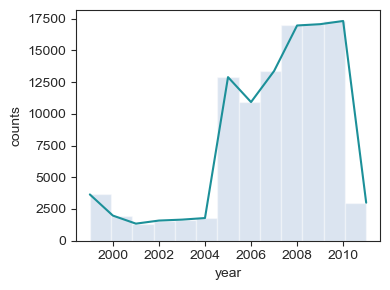

In [22]:
sns.set_style("ticks")

fig, ax = plt.subplots(figsize=(4,3))

xticks = np.arange(2000, 2012, 2)

ax.hist(df["year"], bins=13, alpha=0.4, color="#a6bddb")
ax.plot(studies_per_year['year'], studies_per_year['num_studies'], color="#1c9099")
ax.set(xlabel="year", ylabel="counts", xticks=xticks)
plt.tight_layout()

#### Condition categories

Where to make the cutoff - generalization of the disease? This can be done very broad or  very specific

In [133]:
top_conditions = (df["conditions"].value_counts().head(30))

print(top_conditions)

conditions
hiv infections                                      1691
breast cancer                                       1551
healthy                                             1464
obesity                                              938
hypertension                                         859
asthma                                               830
prostate cancer                                      821
lymphoma                                             721
schizophrenia                                        711
leukemia                                             692
lung cancer                                          659
pain                                                 608
depression                                           580
diabetes mellitus, type 2                            573
colorectal cancer                                    565
cardiovascular diseases                              541
cancer                                               530
diabetes            

In [139]:
category_keywords = {
    "study in healthy individuals":[
        "healthy"
    ],
    "cancer": [
        "cancer", "tumor", "tumour", "oma", "neoplasm", "leukemia", 'myelodysplastic syndromes',
        "myeloproliferative disorders"
    ],
    "cardiovascular": [
        "heart", "cardio", "hypertension", "stroke", "vascular", "coronary",
        "cardiac", "aortic", "myocardial"],
    "infectious": [
        "infection", "rubella", "gonorrhea", "mumps", "hepatitis", "virus",
        "chlamydia", "viral", "bacteria", "bacterial", "covid", "hiv", "influenza", "aids",
        "malaria", "diphtheria", "tetanus"
    ],        
    "neurological": [
        "brain", "neuro", "alzheimer", "parkinson", "epilepsy", "stroke", "autism",
        "myelodysplastic syndrome", "dementia", "cerebral palsy"
    ],
    "metabolic": [
        "diabetes", "obesity", "metabolic", "insulin",  "overweight", "hyperlipidemia",
        "hypercholesterolemia", "dyslipidemia"
    ],
    "respiratory": [
        "lung", "asthma", "copd", "respiratory", "cystic fibrosis", "pulmonary",
        "tuberculosis", "pneumonia"
    ],
    "substance abuse": [
        "substance abuse", "drug", "alcohol", "tobacco", "smoking", "addictive behaviors" ,
        "cocaine-related disorders"
    ],
    "autoimmune diseases": [
        "arthritis", "lupus", "multiple sclerosis", "psoriasis" 
    ],
    "inflammation": [
        "inflammation", "crohn's disease", "sepsis", "atopic dermatitis", "ulcerative colitis",
        "irritable bowel syndrome"
    ],
    "mental health": [
        "depression", "bipolar disorder", "depressive disorder", "anxiety", "schizophrenia",
         "schizoaffective disorder", "attention deficit hyperactivity disorder",
        "psychotic", "post-traumatic stress disorder"
    ], 
    "pain": [
        "pain", "migraine", "fibromyalgia"
    ],
    "blood(-vessel)-related diseases": [
        "atherosclerosis", "anemia", "atrial fibrillation", "blood", "venous thromboembolism"
    ],
    "osteoporosis": ["osteoporosis"],
    "reproduction-related": [
        "pregnancy", "infertility", "birth", "contraception", "erectile dysfunction"
    ],
    'kidney': ["kidney", "cirrhosis", "renal"],
    "eye sight": [
        "eye", "cataract", "myopia", "macular degeneration", "retinopathy"
    ],
    "fatigue": [
        "sleep", "fatigue", "insomnia"
    ]
}

In [140]:
## fct to map conditions
def map_condition_to_category(condition, category_dict=category_keywords):
    if not isinstance(condition, str):
        return "other"
    
    condition = condition.lower()
    # here, entries are classified using keyword-based rules
    # the first match of a keyword wins and category is assigned to one category
    for category, keywords in category_dict.items():
        for kw in keywords:
            if kw in condition:
                return category
    
    return "other"

In [141]:
df["condition_category"] = df["conditions"].apply(map_condition_to_category)

In [142]:
df.groupby(["year", "condition_category"]).size()

year  condition_category             
1999  autoimmune diseases                 65
      blood(-vessel)-related diseases     78
      cancer                             982
      cardiovascular                     299
      eye sight                           23
                                        ... 
2011  pain                                35
      reproduction-related                16
      respiratory                        102
      study in healthy individuals        48
      substance abuse                     39
Length: 247, dtype: int64

In [143]:
# update condition category until other ~ 30 %
df["condition_category"].value_counts(normalize=True)

condition_category
cancer                             0.305081
other                              0.296386
cardiovascular                     0.072314
infectious                         0.057465
metabolic                          0.050373
respiratory                        0.030810
mental health                      0.030017
neurological                       0.023196
autoimmune diseases                0.020124
pain                               0.018946
study in healthy individuals       0.018511
kidney                             0.014598
blood(-vessel)-related diseases    0.014357
substance abuse                    0.011458
inflammation                       0.008859
reproduction-related               0.008695
eye sight                          0.007913
fatigue                            0.007342
osteoporosis                       0.003555
Name: proportion, dtype: float64

In [144]:
# check "other" to update categories
unmapped = (df[df["condition_category"] == "other"]["conditions"].value_counts().head(20))

print(unmapped)

conditions
aging                              101
spinal cord injury                  99
unknown                             97
substance-related disorders         90
diarrhea                            89
opioid-related disorders            86
overactive bladder                  86
graft versus host disease           80
urinary incontinence                72
malnutrition                        70
seasonal allergic rhinitis          69
polycystic ovary syndrome           69
gastroesophageal reflux             69
allergic rhinitis                   68
amyotrophic lateral sclerosis       68
gastroesophageal reflux disease     67
menopause                           67
nicotine dependence                 66
constipation                        66
burns                               65
Name: count, dtype: int64


In [145]:
category_keywords.update({
    "aging": ["aging"],
    "spinal cord injury": ["spinal cord injury"],
    "substance-related disorders": ["substance-related disorders"],
    "diarrhea": ["diarrhea"],
    "opioid-related disorders": ["opioid-related disorders"],
    "incontinence": ["urinary incontinence" ,"overactive bladder"],     
    "allergy": ["allergy", "allergic"],
    "graft versus host disease": ["graft versus host disease"] ,
})

In [146]:
df["condition_category"] = df["conditions"].apply(map_condition_to_category)

In [147]:
df["condition_category"].value_counts(normalize=True)

condition_category
cancer                             0.305081
other                              0.283952
cardiovascular                     0.072314
infectious                         0.057465
metabolic                          0.050373
respiratory                        0.030810
mental health                      0.030017
neurological                       0.023196
autoimmune diseases                0.020124
pain                               0.018946
study in healthy individuals       0.018511
kidney                             0.014598
blood(-vessel)-related diseases    0.014357
substance abuse                    0.011458
inflammation                       0.008859
reproduction-related               0.008695
eye sight                          0.007913
fatigue                            0.007342
allergy                            0.004000
osteoporosis                       0.003555
incontinence                       0.002270
aging                              0.001488
diarrhea     

#### Plot

In [148]:
trends_df = df.groupby(["year", "condition_category"]).size().reset_index(name="count")

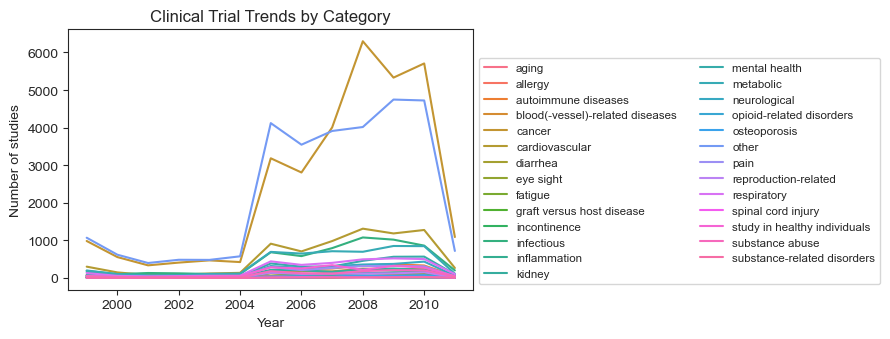

In [150]:
fig, ax = plt.subplots(figsize=(9, 3.5))

pivot_df = trends_df.pivot(index="year", columns="condition_category", values="count").fillna(0)

sns.set_palette("husl", len(pivot_df.columns))
ax.plot(pivot_df, label=pivot_df.columns)
ax.set(xlabel=("Year"), ylabel=("Number of studies"), title=("Clinical Trial Trends by Category"))
ax.legend(ncols=2, bbox_to_anchor=(1, 0),
              loc='lower left', fontsize='small')
plt.tight_layout()


drop at 2011 is artificial, due to lack of new data

<Axes: xlabel='year'>

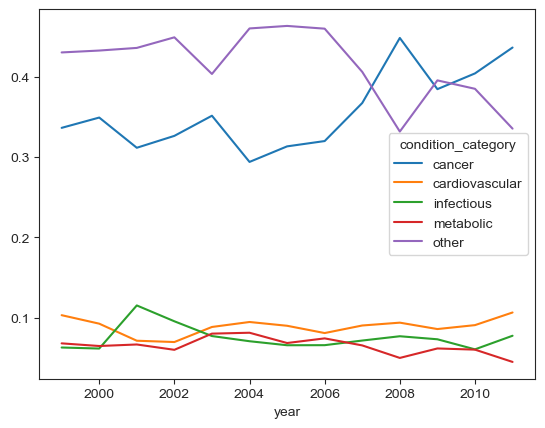

In [91]:
# normalize to show data in proportion
normalized = pivot_df.div(pivot_df.sum(axis=1), axis=0)

normalized.plot()

<Axes: xlabel='year'>

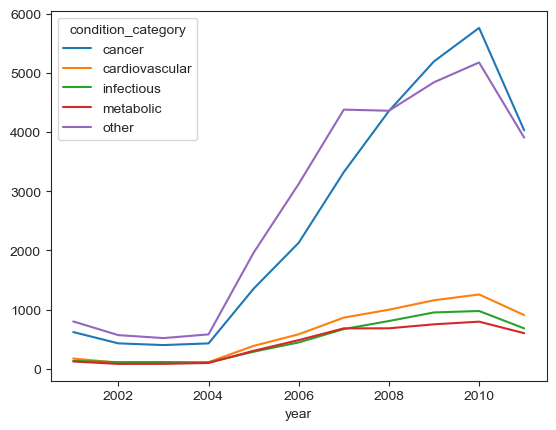

In [92]:
# smooth noise with rolling mean?
pivot_df.rolling(3).mean().plot()

In [151]:
# reduce plotted  categories to make plot less overwhelming and filter out unmapped conditions```
top_categories_excl_other = df[df["condition_category"] != "other"]["condition_category"] .value_counts().head(6).index

filtered_excl_other = trends_df[trends_df["condition_category"].isin(top_categories_excl_other)]

pivot_df_excl_other = filtered_excl_other.pivot(index="year", columns="condition_category", values="count").fillna(0)

Unclassified conditions grouped as ‘other’ are plotted differently clarity

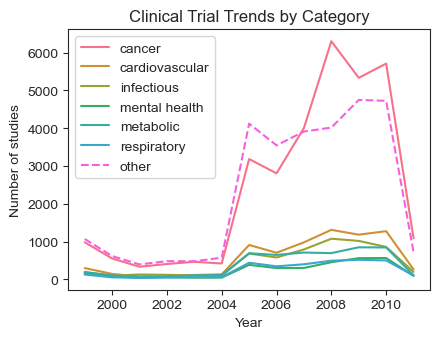

In [156]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

sns.set_palette("husl", 8)

ax.plot(pivot_df_excl_other, label=pivot_df_excl_other.columns)
ax.plot(pivot_df["other"], "--", color="C7", label="other")
ax.set(xlabel=("Year"), ylabel=("Number of studies"), title=("Clinical Trial Trends by Category"))
ax.legend()
plt.tight_layout()


# Key findings  

## Q1 - How did trends in clinical studies change?

* Which categories are increasing?
* Which are stable?
* Any sudden jumps?
* Do proportions change or just total volume?

**Possible interpretation**

All major study categories show a noticeable increase in the number of clinical trials beginning around 2004. However, this increase is substantially more pronounced for cancer-related trials compared to studies focusing on cardiovascular or infectious diseases. This pattern in general suggests a growing emphasize on oncology over time.

Several factorrs may contribute to this trend. In addition to increased scientific and clinical interest in cancer research, technological advances likely played an important role. In particular, the development of Next-Generation Sequencing (NGS) technologies substantially improved the ability to identify genetic alterations, characterize tumors, and develop targeted therapies.
The major transition toward massively parallel, high-throughput sequencing occurred in the mid-2000s, with 2005 often considered a pivotal year for the commercial availability of modern NGS platforms. These technological advances may have accelerated both the number and scope of all studies, but especially those of cancer-related clinical studies. Refs: Sarig O, Sprecher E. The molecular revolution in cutaneous biology: era of next-generation sequencing. J Invest Dermatol 2017;137:e79–e82; https://www.cd-genomics.com/resource-when-was-ngs-invented.html